
## 1. Import libraries


In [1]:

import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.optimize import linear_sum_assignment

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
np.random.seed(42)



## 2. Helper functions


In [2]:

FIG_DIR = Path('figures_eps')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(name):
    plt.savefig(FIG_DIR / f"{name}.eps", format='eps', dpi=600, bbox_inches='tight')


def clustering_scores(X, labels, y_true=None):
    result = {}
    unique_labels = np.unique(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters >= 2:
        result['Silhouette Score'] = silhouette_score(X, labels)
        result['Davies-Bouldin Index'] = davies_bouldin_score(X, labels)
        result['Calinski-Harabasz Index'] = calinski_harabasz_score(X, labels)
    else:
        result['Silhouette Score'] = np.nan
        result['Davies-Bouldin Index'] = np.nan
        result['Calinski-Harabasz Index'] = np.nan

    if y_true is not None:
        result['Adjusted Rand Index'] = adjusted_rand_score(y_true, labels)
        result['Normalized Mutual Info'] = normalized_mutual_info_score(y_true, labels)

    result['Clusters Found'] = n_clusters
    result['Noise Points'] = int(np.sum(labels == -1)) if -1 in labels else 0
    return result


def plot_cluster_scatter(X_2d, labels, title, file_name):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=10)
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(alpha=0.3)
    save_fig(file_name)
    plt.show()


def map_clusters_to_labels(y_true, cluster_labels):
    valid_mask = cluster_labels != -1
    y_true_valid = y_true[valid_mask]
    y_pred_valid = cluster_labels[valid_mask]

    true_classes = np.unique(y_true_valid)
    pred_clusters = np.unique(y_pred_valid)

    cost = np.zeros((len(true_classes), len(pred_clusters)), dtype=int)
    for i, t in enumerate(true_classes):
        for j, c in enumerate(pred_clusters):
            cost[i, j] = -np.sum((y_true_valid == t) & (y_pred_valid == c))

    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {pred_clusters[j]: true_classes[i] for i, j in zip(row_ind, col_ind)}

    mapped = np.full_like(cluster_labels, fill_value=-1)
    for cluster, true_class in mapping.items():
        mapped[cluster_labels == cluster] = true_class
    return mapped, mapping


In [6]:
from pathlib import Path
import zipfile
import pandas as pd

ZIP_PATH = Path("UCI HAR Dataset.zip")   # uploaded zip file
EXTRACT_DIR = Path("har_extracted")
DATA_DIR = EXTRACT_DIR / "UCI HAR Dataset"
if not DATA_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)

feature_names = pd.read_csv(
    DATA_DIR / "features.txt",
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)["feature"].tolist()

X_train = pd.read_csv(
    DATA_DIR / "train" / "X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    DATA_DIR / "train" / "y_train.txt",
    header=None,
    names=["Activity"]
)

activity_labels = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["Activity", "Activity_Name"]
)

# Set column names
X_train.columns = feature_names

# Convert labels to series
y_train = y_train["Activity"]

# Map numeric activity IDs to names
label_map = dict(zip(activity_labels["Activity"], activity_labels["Activity_Name"]))
y_names = y_train.map(label_map)

print("Feature matrix shape:", X_train.shape)
print("Target shape:", y_train.shape)
display(activity_labels.head())
display(y_names.head())

Extracting dataset...
Feature matrix shape: (7352, 561)
Target shape: (7352,)


,Activity,Activity_Name
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING


0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: Activity, dtype: object


## 4. Preprocessing
- check missing values
- standardize features


In [7]:

print('Missing values in X_train:', int(X_train.isna().sum().sum()))
print('Missing values in y_train:', int(y_train.isna().sum()))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print('Scaled feature matrix shape:', X_scaled.shape)


Missing values in X_train: 0
Missing values in y_train: 0
Scaled feature matrix shape: (7352, 561)



## 5. Basic EDA
Show the class distribution and a few representative feature distributions.


In [8]:

activity_counts = y_names.value_counts().sort_index()
activity_counts


Activity
LAYING                1407
SITTING               1286
STANDING              1374
WALKING               1226
WALKING_DOWNSTAIRS     986
WALKING_UPSTAIRS      1073
Name: count, dtype: int64

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


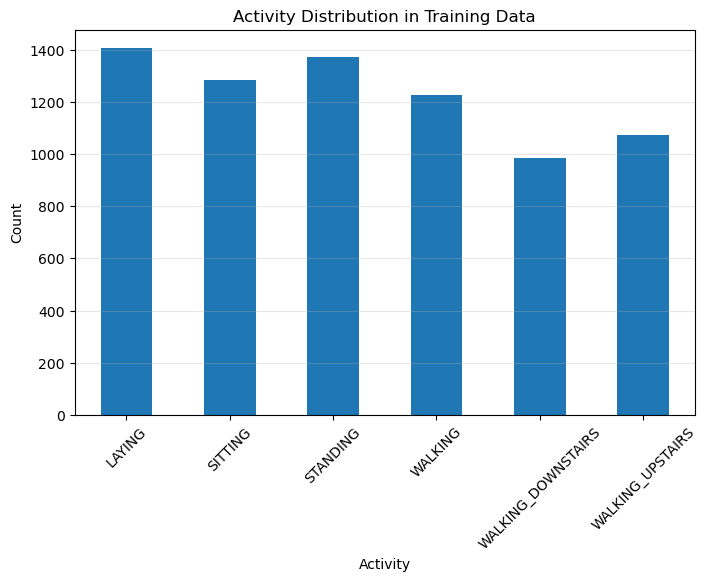

In [9]:

plt.figure(figsize=(8, 5))
activity_counts.plot(kind='bar')
plt.title('Activity Distribution in Training Data')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
save_fig('activity_distribution_barplot')
plt.show()


In [10]:

selected_features = [
    'tBodyAcc-mean()-X',
    'tBodyAcc-mean()-Y',
    'tBodyAcc-mean()-Z',
    'tBodyGyro-mean()-X'
]

X_train[selected_features].describe().T


,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,0.274488,0.070261,-1.00000,0.262975,0.277193,0.288461,1.000000
tBodyAcc-mean()-Y,7352.0,-0.017695,0.040811,-1.00000,-0.024863,-0.017219,-0.010783,1.000000
tBodyAcc-mean()-Z,7352.0,-0.109141,0.056635,-1.00000,-0.120993,-0.108676,-0.097794,1.000000
tBodyGyro-mean()-X,7352.0,-0.027184,0.182156,-0.91405,-0.043398,-0.027677,-0.010528,0.738953


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


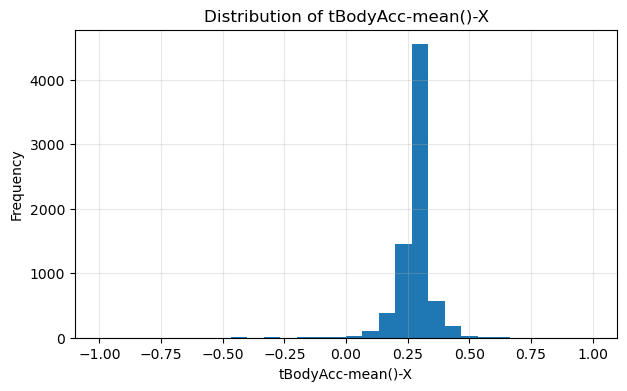

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


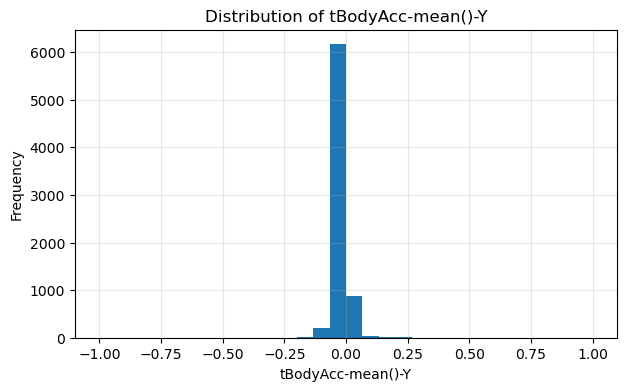

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


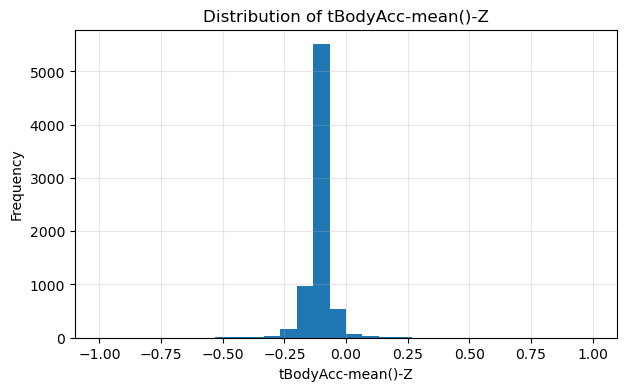

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


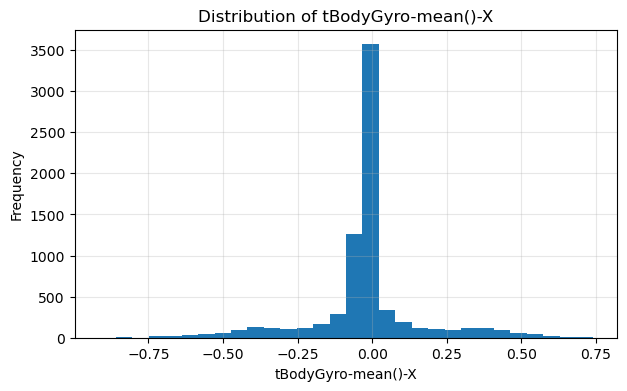

In [11]:

for col in selected_features:
    plt.figure(figsize=(7, 4))
    plt.hist(X_train[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    save_fig(f"hist_{col.replace('/', '_').replace('(', '').replace(')', '')}")
    plt.show()



## 6. PCA for 2D visualization
We reduce the standardized data to 2 principal components for plotting.


In [12]:

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

print('Explained variance ratio:', pca_2d.explained_variance_ratio_)
print('Total explained variance:', pca_2d.explained_variance_ratio_.sum())


Explained variance ratio: [0.50781172 0.0658068 ]
Total explained variance: 0.5736185255809918


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


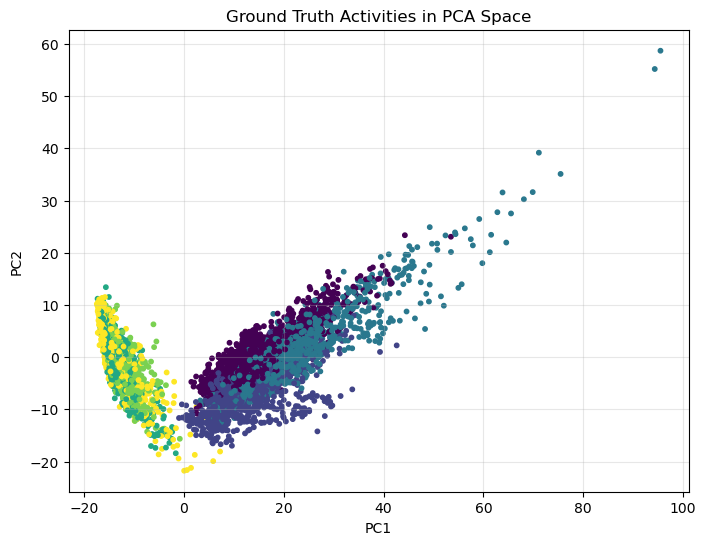

In [22]:

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, s=10)
plt.title('Ground Truth Activities in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
save_fig('ground_truth_pca_scatter')
plt.show()



## 7. K-Means Clustering


In [14]:

k_values = list(range(2, 9))
kmeans_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    kmeans_rows.append({
        'k': k,
        'WCSS (Inertia)': km.inertia_,
        'Silhouette Score': silhouette_score(X_scaled, labels_km)
    })

kmeans_elbow_df = pd.DataFrame(kmeans_rows)
kmeans_elbow_df


,k,WCSS (Inertia),Silhouette Score
0,2,2.336224e+06,0.396505
1,3,2.081850e+06,0.327408
2,4,1.976453e+06,0.165163
3,5,1.875066e+06,0.130639
4,6,1.818790e+06,0.108641
5,7,1.776519e+06,0.111424
6,8,1.737555e+06,0.073861


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


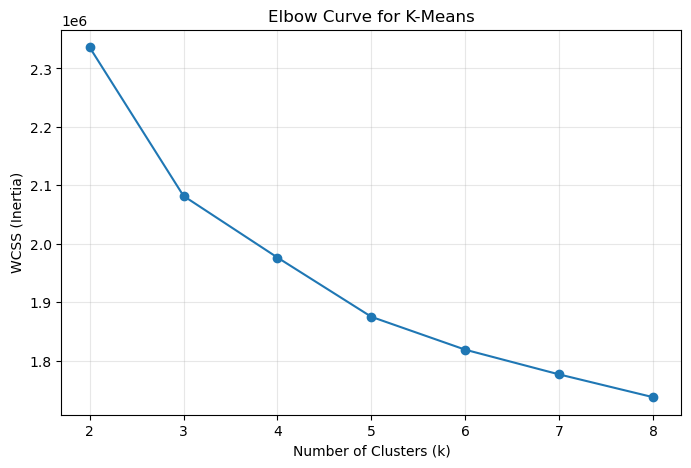

In [15]:

plt.figure(figsize=(8, 5))
plt.plot(kmeans_elbow_df['k'], kmeans_elbow_df['WCSS (Inertia)'], marker='o')
plt.title('Elbow Curve for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(alpha=0.3)
save_fig('kmeans_elbow_curve')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


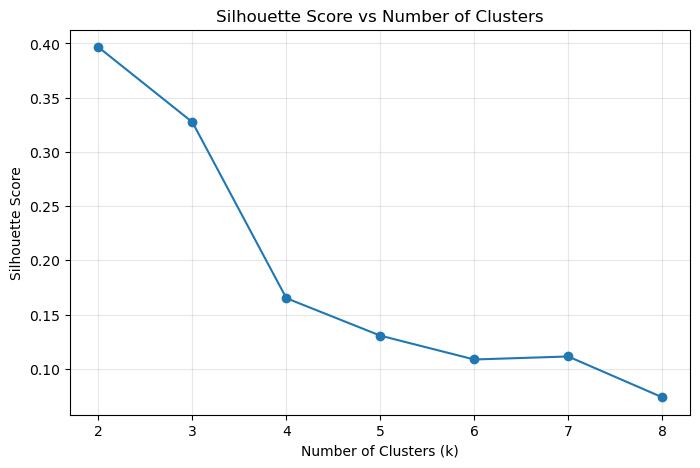

In [16]:

plt.figure(figsize=(8, 5))
plt.plot(kmeans_elbow_df['k'], kmeans_elbow_df['Silhouette Score'], marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(alpha=0.3)
save_fig('kmeans_silhouette_curve')
plt.show()


In [17]:

best_k = int(kmeans_elbow_df.loc[kmeans_elbow_df['Silhouette Score'].idxmax(), 'k'])
print('Best k selected using highest silhouette score =', best_k)


Best k selected using highest silhouette score = 2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


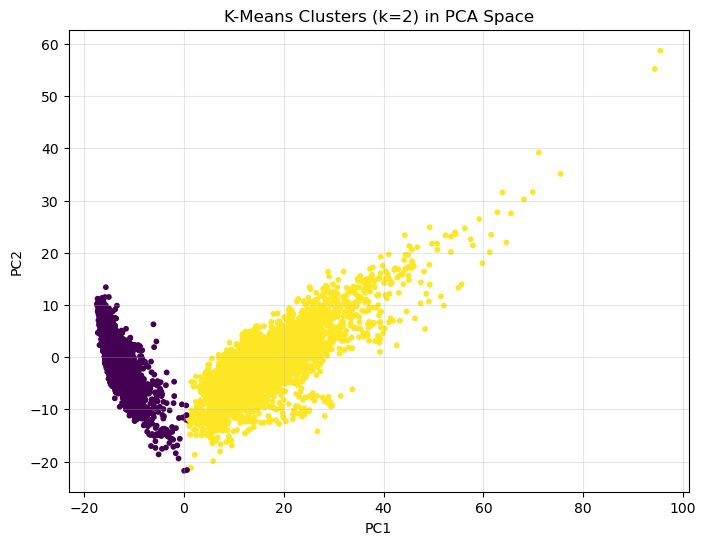

In [18]:

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

plot_cluster_scatter(X_pca, kmeans_labels, f'K-Means Clusters (k={best_k}) in PCA Space', 'kmeans_pca_clusters')



## 8. DBSCAN Clustering


In [24]:
dbscan_results = []

for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_samples in [3, 5, 10]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = db.fit_predict(X_pca)   # use PCA-reduced data

        mask = labels_db != -1
        filtered_labels = labels_db[mask]
        filtered_data = X_pca[mask]

        n_clusters = len(set(filtered_labels))
        noise_points = int(np.sum(labels_db == -1))

        if n_clusters >= 2 and len(filtered_data) > 0:
            sil = silhouette_score(filtered_data, filtered_labels)
        else:
            sil = np.nan

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters_found': n_clusters,
            'noise_points': noise_points,
            'silhouette_score': sil
        })

dbscan_tuning_df = pd.DataFrame(dbscan_results).sort_values(
    by=['silhouette_score', 'clusters_found'],
    ascending=[False, False]
)

dbscan_tuning_df.head(10)


,eps,min_samples,clusters_found,noise_points,silhouette_score
17,2.0,10,2,91,0.712350
16,2.0,5,2,58,0.709825
12,1.5,3,6,54,0.547963
14,1.5,10,4,211,0.523952
11,1.2,10,5,320,0.490410
5,0.8,10,4,777,0.447100
13,1.5,5,5,87,0.440630
9,1.2,3,11,85,0.420905
8,1.0,10,7,510,0.418233
10,1.2,5,12,137,0.389684


In [25]:

best_dbscan_row = dbscan_tuning_df.dropna(subset=['silhouette_score']).iloc[0]
best_eps = float(best_dbscan_row['eps'])
best_min_samples = int(best_dbscan_row['min_samples'])

print('Best DBSCAN parameters:')
print('eps =', best_eps)
print('min_samples =', best_min_samples)


Best DBSCAN parameters:
eps = 2.0
min_samples = 10


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


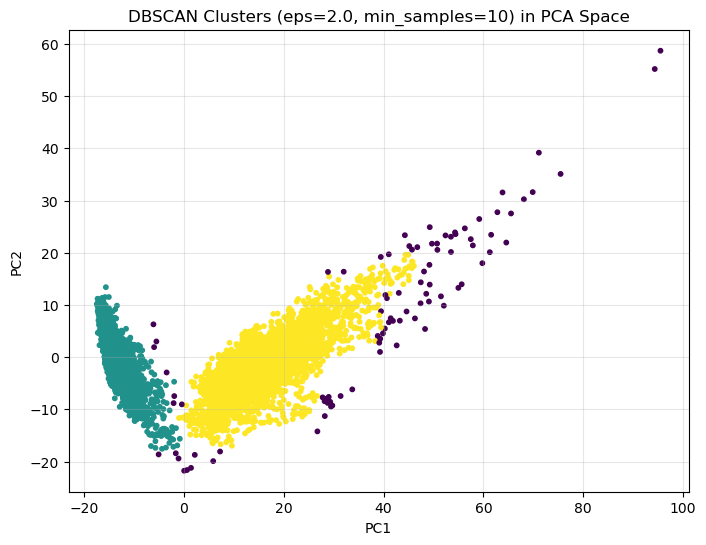

In [31]:

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_pca)

plot_cluster_scatter(
    X_pca,
    dbscan_labels,
    f'DBSCAN Clusters (eps={best_eps}, min_samples={best_min_samples}) in PCA Space',
    'dbscan_pca_clusters'
)



## 9. Hierarchical Agglomerative Clustering


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


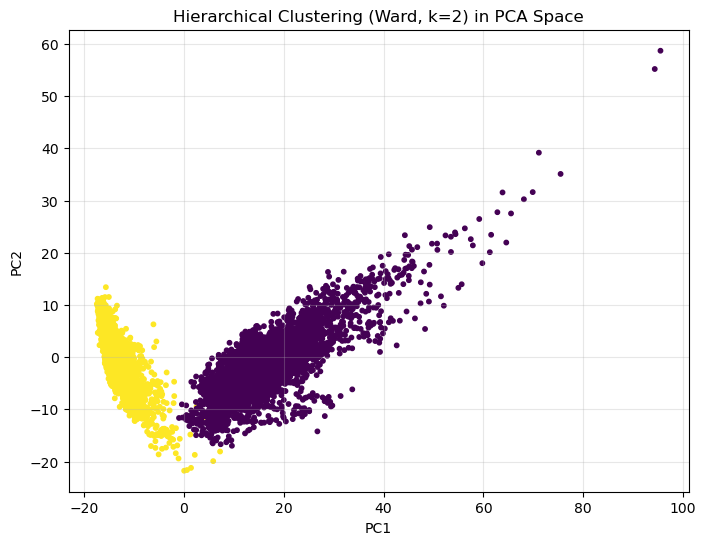

In [40]:

hac = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hac_labels = hac.fit_predict(X_scaled)

plot_cluster_scatter(X_pca, hac_labels, f'Hierarchical Clustering (Ward, k={best_k}) in PCA Space', 'hierarchical_pca_clusters')


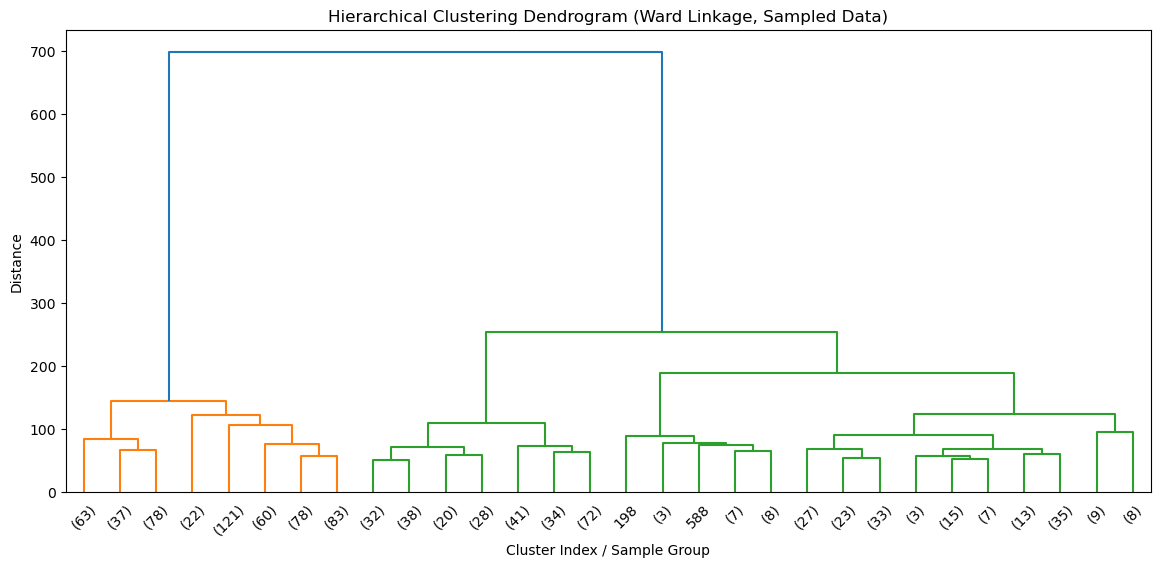

In [33]:

# Dendrogram on a subset because hierarchical plotting on the full dataset is too expensive.
sample_size = 1000
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, Sampled Data)')
plt.xlabel('Cluster Index / Sample Group')
plt.ylabel('Distance')
save_fig('hierarchical_dendrogram')
plt.show()



## 10. Evaluation metrics for all algorithms
Internal metrics:
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

External metrics using true activity labels:
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)


In [34]:

results = {
    'K-Means': clustering_scores(X_scaled, kmeans_labels, y_train),
    'DBSCAN': clustering_scores(X_scaled, dbscan_labels, y_train),
    'Hierarchical': clustering_scores(X_scaled, hac_labels, y_train)
}

results_df = pd.DataFrame(results).T
results_df


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Adjusted Rand Index,Normalized Mutual Info,Clusters Found,Noise Points
K-Means,0.396505,1.068868,5626.012753,0.328453,0.543257,2.0,0.0
DBSCAN,0.392564,1.728666,3029.626219,0.329251,0.538888,2.0,91.0
Hierarchical,0.396056,1.069820,5608.277236,0.331866,0.555477,2.0,0.0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


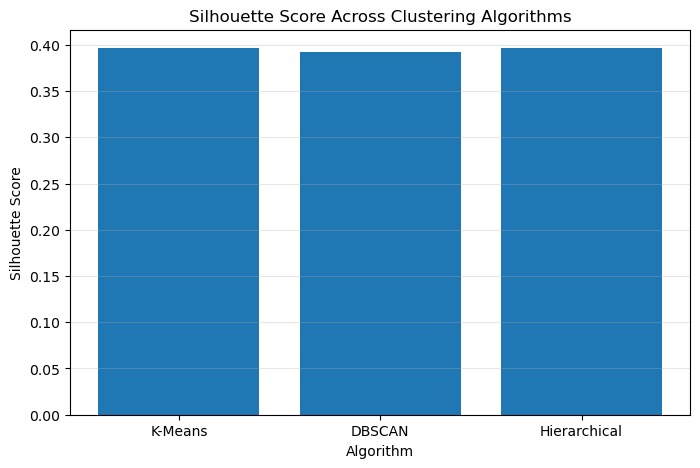

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


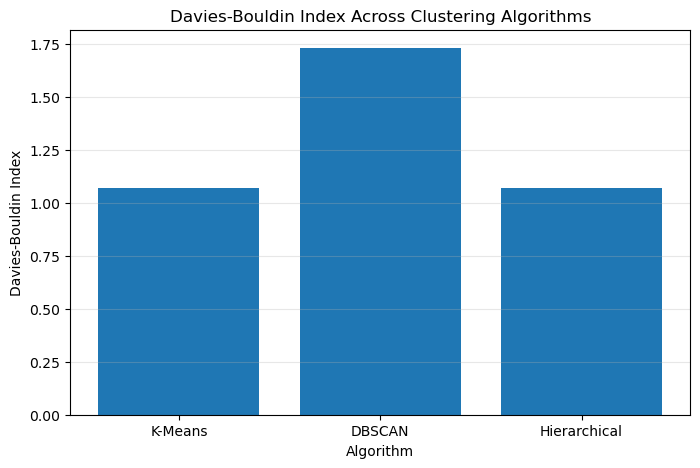

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


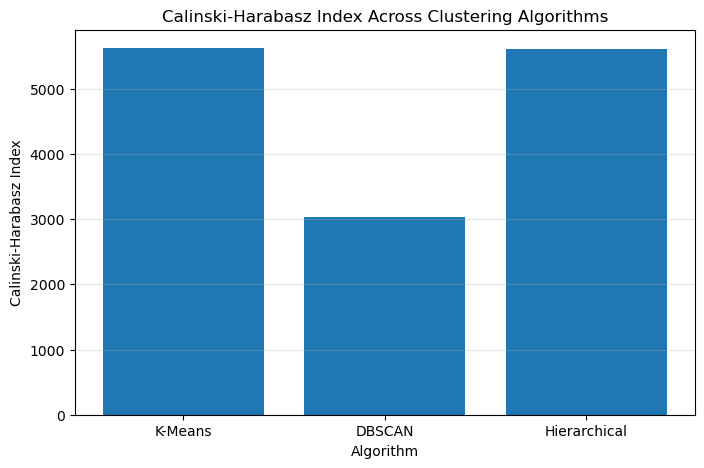

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


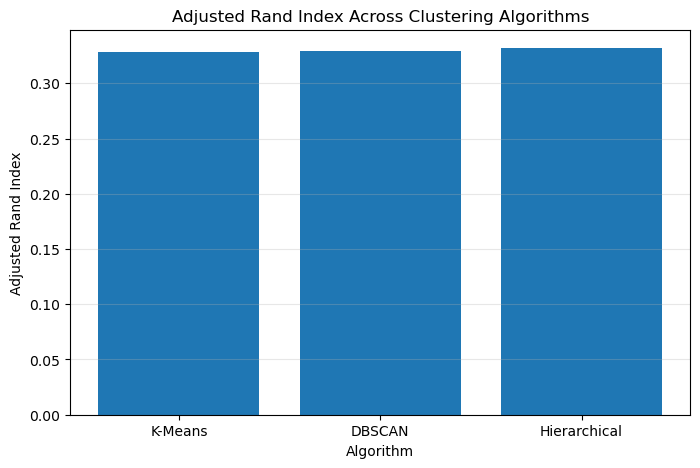

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


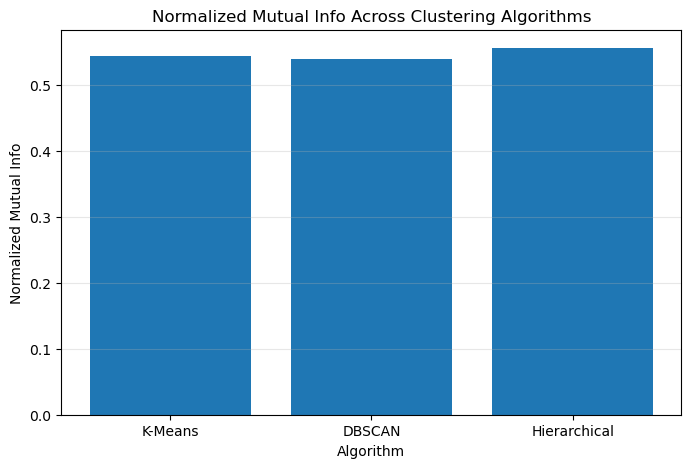

In [35]:

metrics_to_plot = [
    'Silhouette Score',
    'Davies-Bouldin Index',
    'Calinski-Harabasz Index',
    'Adjusted Rand Index',
    'Normalized Mutual Info'
]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df.index, results_df[metric])
    plt.title(f'{metric} Across Clustering Algorithms')
    plt.xlabel('Algorithm')
    plt.ylabel(metric)
    plt.grid(axis='y', alpha=0.3)
    save_fig(metric.lower().replace(' ', '_').replace('-', '_'))
    plt.show()


In [36]:

mapped_kmeans, kmeans_mapping = map_clusters_to_labels(y_train.to_numpy(), kmeans_labels)
cm_kmeans = confusion_matrix(y_train, mapped_kmeans, labels=sorted(y_train.unique()))

cm_df = pd.DataFrame(
    cm_kmeans,
    index=[f'True_{label_map[i]}' for i in sorted(y_train.unique())],
    columns=[f'Pred_{label_map[i]}' for i in sorted(y_train.unique())]
)

cm_df


,Pred_WALKING,Pred_WALKING_UPSTAIRS,Pred_WALKING_DOWNSTAIRS,Pred_SITTING,Pred_STANDING,Pred_LAYING
True_WALKING,1226,0,0,0,0,0
True_WALKING_UPSTAIRS,1065,0,0,0,0,8
True_WALKING_DOWNSTAIRS,986,0,0,0,0,0
True_SITTING,1,0,0,0,0,1285
True_STANDING,0,0,0,0,0,1374
True_LAYING,11,0,0,0,0,1396


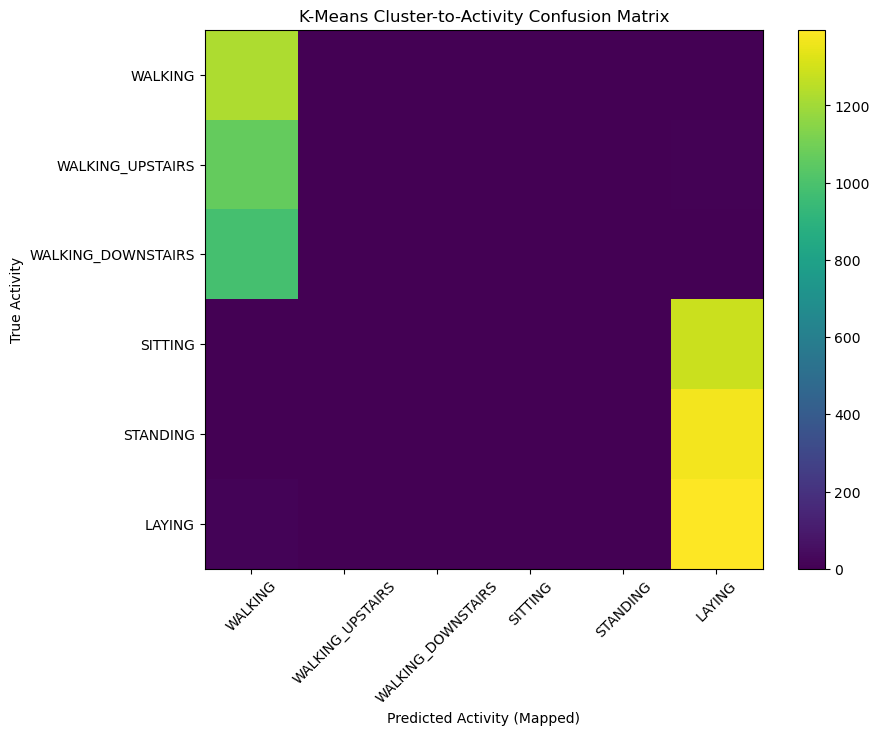

In [37]:

plt.figure(figsize=(9, 7))
plt.imshow(cm_kmeans, aspect='auto')
plt.title('K-Means Cluster-to-Activity Confusion Matrix')
plt.xlabel('Predicted Activity (Mapped)')
plt.ylabel('True Activity')
plt.xticks(range(len(label_map)), [label_map[i] for i in sorted(label_map)], rotation=45)
plt.yticks(range(len(label_map)), [label_map[i] for i in sorted(label_map)])
plt.colorbar()
save_fig('kmeans_confusion_matrix_mapped')
plt.show()


In [38]:

print('K-Means Elbow / Silhouette Table')
display(kmeans_elbow_df)

print('DBSCAN Tuning Table (Top 10)')
display(dbscan_tuning_df.head(10))

print('Final Metrics Comparison')
display(results_df)


K-Means Elbow / Silhouette Table


,k,WCSS (Inertia),Silhouette Score
0,2,2.336224e+06,0.396505
1,3,2.081850e+06,0.327408
2,4,1.976453e+06,0.165163
3,5,1.875066e+06,0.130639
4,6,1.818790e+06,0.108641
5,7,1.776519e+06,0.111424
6,8,1.737555e+06,0.073861


DBSCAN Tuning Table (Top 10)


,eps,min_samples,clusters_found,noise_points,silhouette_score
17,2.0,10,2,91,0.712350
16,2.0,5,2,58,0.709825
12,1.5,3,6,54,0.547963
14,1.5,10,4,211,0.523952
11,1.2,10,5,320,0.490410
5,0.8,10,4,777,0.447100
13,1.5,5,5,87,0.440630
9,1.2,3,11,85,0.420905
8,1.0,10,7,510,0.418233
10,1.2,5,12,137,0.389684


Final Metrics Comparison


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Adjusted Rand Index,Normalized Mutual Info,Clusters Found,Noise Points
K-Means,0.396505,1.068868,5626.012753,0.328453,0.543257,2.0,0.0
DBSCAN,0.392564,1.728666,3029.626219,0.329251,0.538888,2.0,91.0
Hierarchical,0.396056,1.069820,5608.277236,0.331866,0.555477,2.0,0.0
